In [25]:
def DM_for_one_run(task, subId, run):

    ###### input ######
    # task = "contact" (string "contact", "distance", "emotions" )
    #subId = "sub-01" (string sub-<two digit number>) 
    # run = 1 (int)

    import pandas as pd
    import os
    import re
    import nilearn
    import numpy as np
    from nilearn.plotting import plot_design_matrix
    import matplotlib.pyplot as plt

    # path on triton = /scratch/nbe/prevent/Experiment1/Data_BIDS/derivatives/keras/{subId}/logs
    folder_path = f"/scratch/nbe/prevent/Experiment1/Data_BIDS/derivatives/keras/{subId}/logs"

    log_file_name = f"virtual_contact_sce{run}.log"
    file_path = os.path.join(folder_path, log_file_name)

    
    expected_columns = ["Subject", "Trial", "Event Type", "Code", "Time", "TTime",
        "Uncertainty", "Duration", "Uncertainty", "ReqTime",
        "ReqDur", "Stim Type", "Pair Index"]
    
    # Regex pattern to match only valid Subject lines like S1-Se1, ..., S42-Se5
    valid_subject_pattern = re.compile(r'^S([1-9]|[1-4][0-9])-Se([1-5])\t')

    # Initialize list for rows
    rows = []
    columns = None
    correction_count = 0
    
    with open(file_path, "r") as f:
        for line in f:
            stripped = line.strip()
    
            # extract the header of the log file and check it with expected headers
            if stripped.startswith("Subject\t"):
                columns = stripped.split("\t")
                try:
                    if columns != expected_columns:
                        raise ValueError("Column mismatch")
                except ValueError as e:
                    print("❌ Error:", e)
                    print("File columns:     ", columns)
                    print("Expected columns: ", expected_columns)
                    raise
                continue
    
            # if the line is not a header, check that it is a data line and then extract rows from it
            if valid_subject_pattern.match(line):
                parts = stripped.split("\t")
    
                # in case row has some missing values replace it with blank string and warn the user.
                if len(parts) < len(columns):
                    missing = len(columns) - len(parts)
                    parts += [""] * missing
                    correction_count += 1
                    
                    # Uncomment the following block to print details about each corrected line
                    # print(f"\n⚠️ Warning: Line {line} has {len(parts)} columns, expected {len(columns)}.")
                    # print(f"➤ Added {missing} empty string(s) to match column count.")
                    # print(f"Original line: {stripped}")
                    
                rows.append(parts)


    if correction_count > 0:
            print(f"⚠️ {correction_count} line(s) had missing columns and were auto-corrected with empty values.")



    df = pd.DataFrame(rows, columns=columns)
    
    # Convert "Time" column values to numeric. 
    df['Time'] = pd.to_numeric(df['Time'], errors='coerce') 
    
    
    # Filter for rows where 'Code' ends with '_vid' and ignore Ukraniane type
    df_vids = df[
        df['Code'].str.endswith('_vid', na=False) &
        ~df['Code'].str.startswith(('uk1_', 'uk2_'), na=False)
    ]
    
    # Build final dataset
    event_df = pd.DataFrame({
        "onset": df_vids["Time"]* 1e-4,
        "duration": 35,
        "trial_type": df_vids["Code"].str.replace(r'(1|2)_vid$', '', regex=True)
    })
    
    event_df = event_df.reset_index(drop = True)
    
    frame_times = df[df['Code']== "30"]['Time']* 1e-4
    frame_times = frame_times.to_numpy()

    ################# end of func ########################


    ############### new func ###########################
    
    # path on triton = /scratch/nbe/prevent/Experiment1/Data_BIDS/derivatives/fmriprep{subId}/func
    
    nifti_folder_path = os.path.expanduser(f"~/Desktop/fmriprep/{subId}/func") # HARDCODED_PATH
    run_str = f"run-{run:02}"

    matched_nifti_path = None
    for fname in os.listdir(nifti_folder_path):
        if (
            "2009" in fname
            and task in fname
            and fname.endswith("bold.nii.gz")
            and run_str in fname
        ):
            matched_nifti_path = os.path.join(nifti_folder_path, fname)
            print(f"✅ Found file for {run_str}: {fname}")
            break 

    else:
        raise ValueError(f"❌ No file found for {run_str}")
        
    
    confounds, sample_mask = nilearn.interfaces.fmriprep.load_confounds(
        matched_nifti_path, strategy=('motion', 'wm_csf','global_signal'), motion='basic', wm_csf='basic', global_signal='basic')
    
    # if nii.gz data has more volumes in the end of the experiment, we drop them 
    if len(confounds) > len(frame_times):
        rows_to_drop = len(confounds) - len(frame_times)
        confounds = confounds.iloc[:len(frame_times)] 
        print(f"⚠️ Dropped {rows_to_drop} extra row(s) from the bottom.")
    
    design_matrix = nilearn.glm.first_level.make_first_level_design_matrix(frame_times, event_df, hrf_model = "spm", add_regs = confounds, drift_model='cosine')

    plot_design_matrix(design_matrix)
        
    return design_matrix, matched_nifti_path

design matrix: frame times, event df, confounds
confounds: nifti path
event df and fram times: log file
#TODO: trim all nifti files and store them and never trim them again :|



In [36]:
def con_map_one_sub(dms,paths):
    #dms = list of pandas df, len(runs per sub), each df is a design matrix for one run
    #paths = list of strings, len(runs per sub), each str is a path to a nifti image for one run
    
    from nilearn.image import index_img, load_img
    from nilearn.glm.first_level import FirstLevelModel
    from nilearn.plotting import plot_stat_map



    trimmed_paths = []
    for i, path in enumerate(paths):
        img = load_img(path)
        trimmed_img = index_img(img,slice( len(dms[i])))
    
        out_path = f"~/Desktop/trimmed/trimmed_bold_run{i+1}.nii.gz" # HARDCODED_PATH
        trimmed_img.to_filename(out_path)
        trimmed_paths.append(out_path)
    
    
    
    first_level_model = FirstLevelModel(t_r=1.6,hrf_model='spm')
    
    # Fit model to all 5 runs
    first_level_model = first_level_model.fit(trimmed_paths, design_matrices= dms)
    
    # Use the same contrast across all runs
    contrast_map = first_level_model.compute_contrast('fi', output_type='z_score')
    
    
    plot_stat_map(contrast_map, title='Contrast')

    return contrast_map


⚠️ 298 line(s) had missing columns and were auto-corrected with empty values.
✅ Found file for run-01: sub-01_task-contact_run-01_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz
⚠️ Dropped 1 extra row(s) from the bottom.
⚠️ 299 line(s) had missing columns and were auto-corrected with empty values.
✅ Found file for run-02: sub-01_task-contact_run-02_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz
⚠️ Dropped 1 extra row(s) from the bottom.
⚠️ 295 line(s) had missing columns and were auto-corrected with empty values.
✅ Found file for run-03: sub-01_task-contact_run-03_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz
⚠️ Dropped 1 extra row(s) from the bottom.
⚠️ 295 line(s) had missing columns and were auto-corrected with empty values.
✅ Found file for run-04: sub-01_task-contact_run-04_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz
⚠️ Dropped 1 extra row(s) from the bottom.
⚠️ 297 line(s) had missing columns and were auto-corrected with empty values.
✅ Found file for run-05: s

/tmp/ipykernel_73137/513759843.py:32: UserWarning: If design matrices are supplied, [hrf_model, t_r] will be ignored.
  first_level_model = first_level_model.fit(trimmed_paths, design_matrices= dms)
/tmp/ipykernel_73137/513759843.py:32: UserWarning: Mean values of 0 observed. The data have probably been centered.Scaling might not work as expected
  first_level_model = first_level_model.fit(trimmed_paths, design_matrices= dms)
/tmp/ipykernel_73137/513759843.py:35: UserWarning: One contrast given, assuming it for all 5 runs
  contrast_map = first_level_model.compute_contrast('fi - (bra+ru+so)', output_type='z_score')


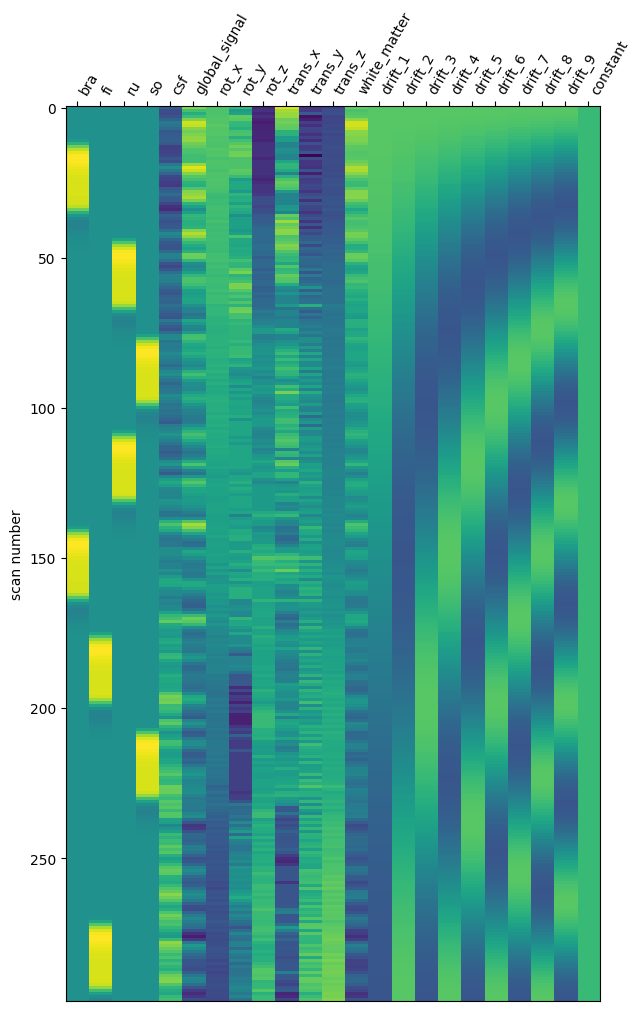

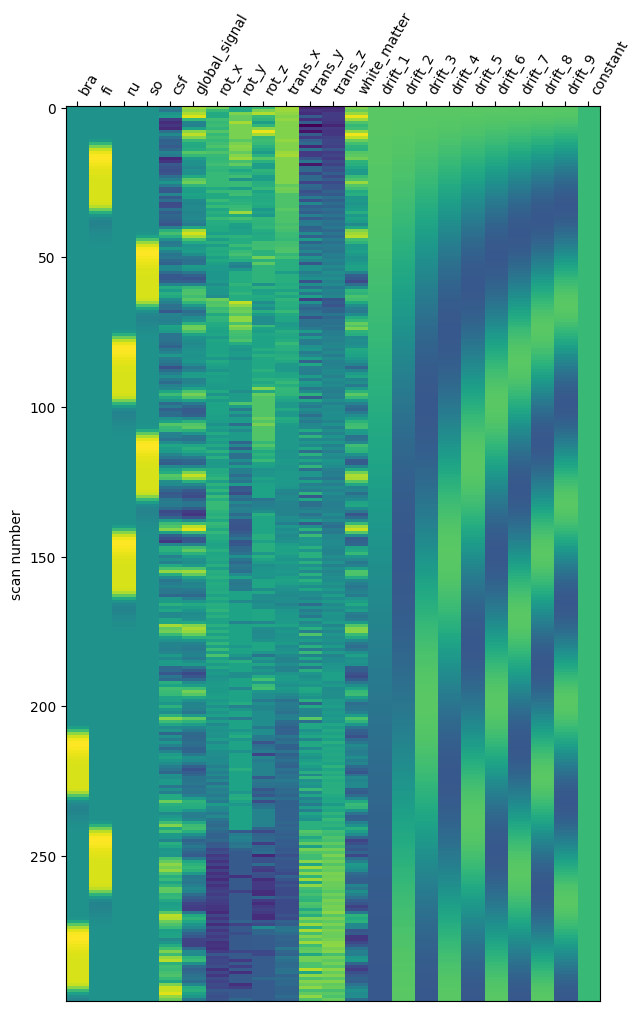

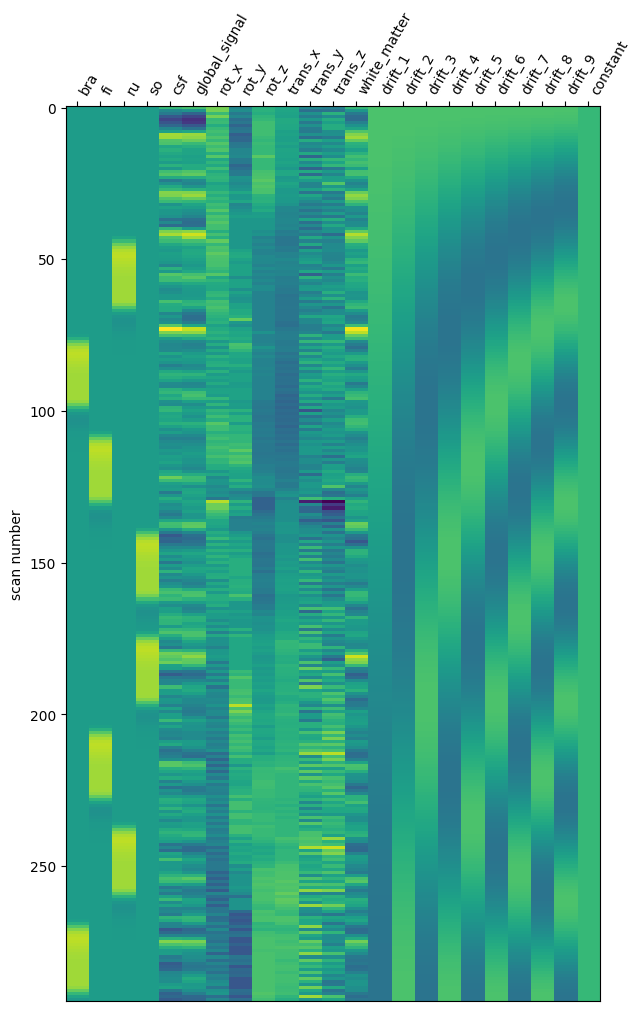

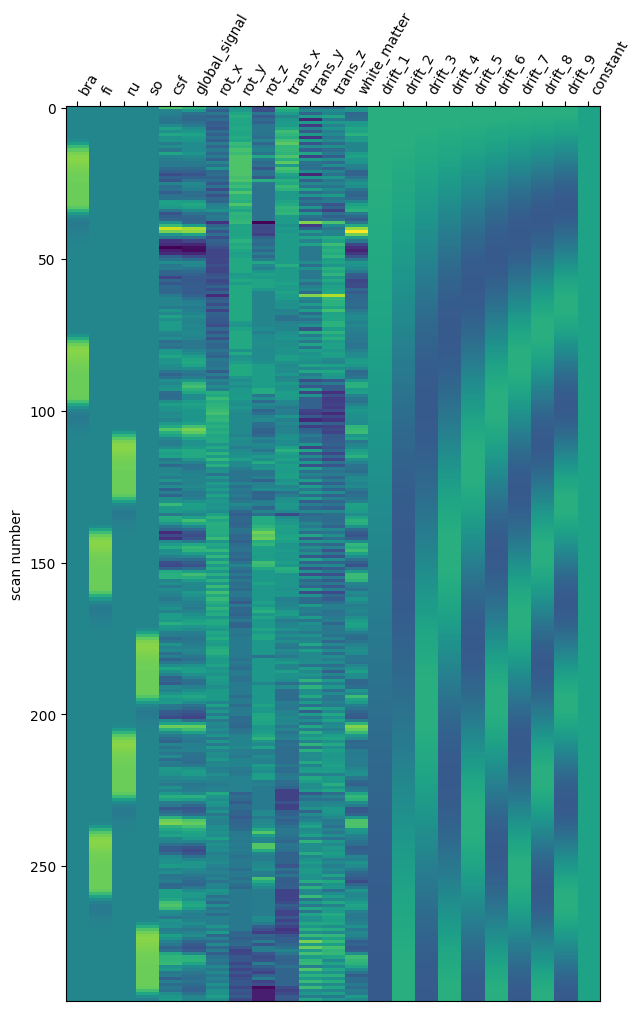

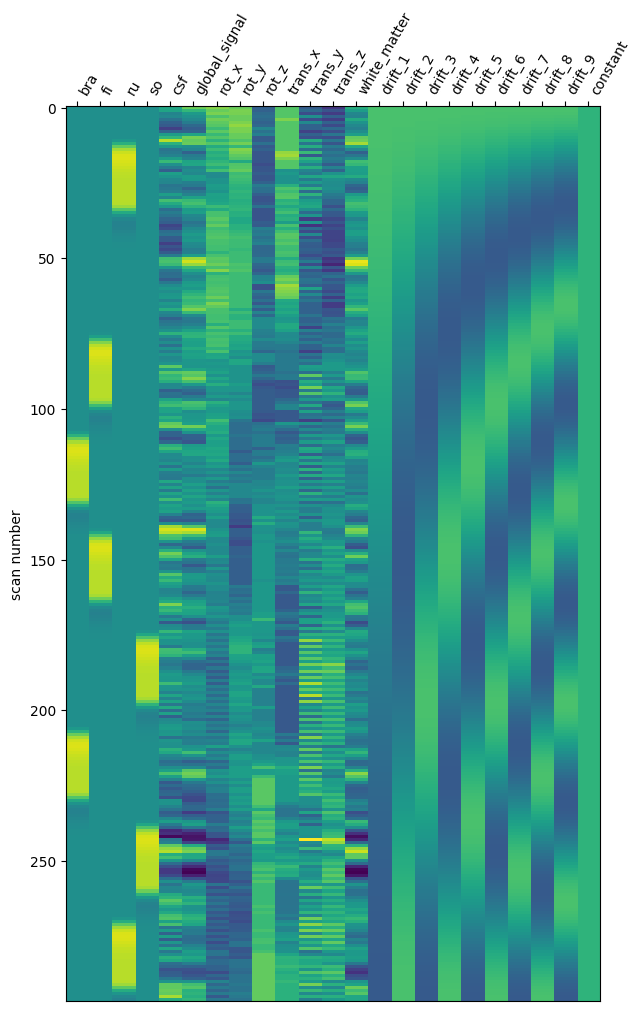

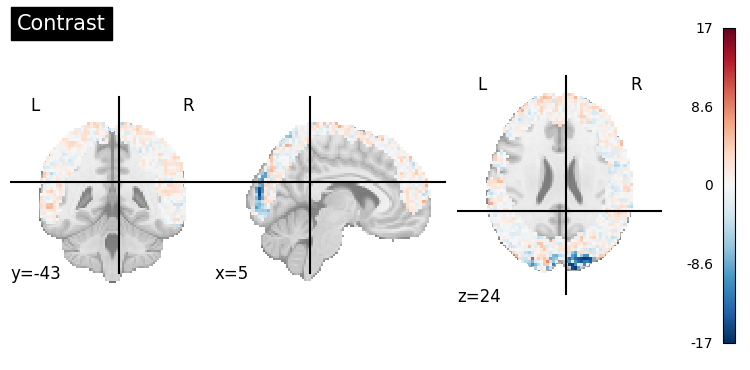

In [29]:
#for subNo in range (1,43):
    #subId = f"sub-{subNo:02}"
task = "contact"
subId = "sub-01"

dms, paths = map(list, zip(*[DM_for_one_run(task, subId, run) for run in range(1, 6)]))
con_map_one_sub(dms, paths)

/tmp/ipykernel_73137/3914874941.py:25: UserWarning: If design matrices are supplied, [hrf_model, t_r] will be ignored.
  first_level_model = first_level_model.fit(trimmed_paths, design_matrices= dms)
/tmp/ipykernel_73137/3914874941.py:25: UserWarning: Mean values of 0 observed. The data have probably been centered.Scaling might not work as expected
  first_level_model = first_level_model.fit(trimmed_paths, design_matrices= dms)
/tmp/ipykernel_73137/3914874941.py:28: UserWarning: One contrast given, assuming it for all 5 runs
  contrast_map = first_level_model.compute_contrast('so', output_type='z_score')


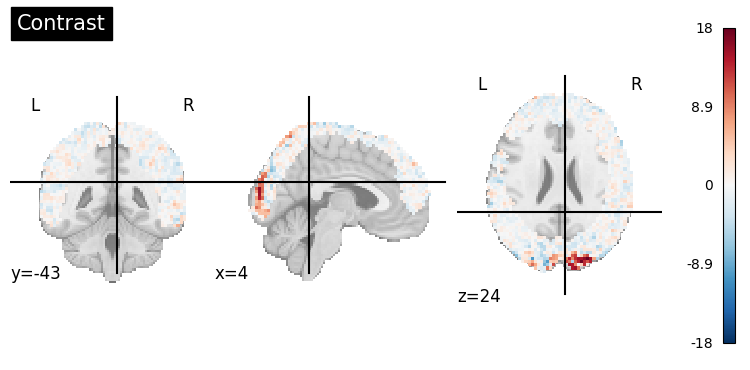

In [33]:
con_map_one_sub(dms, paths)

/tmp/ipykernel_73137/186372498.py:25: UserWarning: If design matrices are supplied, [hrf_model, t_r] will be ignored.
  first_level_model = first_level_model.fit(trimmed_paths, design_matrices= dms)
/tmp/ipykernel_73137/186372498.py:25: UserWarning: Mean values of 0 observed. The data have probably been centered.Scaling might not work as expected
  first_level_model = first_level_model.fit(trimmed_paths, design_matrices= dms)
/tmp/ipykernel_73137/186372498.py:28: UserWarning: One contrast given, assuming it for all 5 runs
  contrast_map = first_level_model.compute_contrast('fi', output_type='z_score')


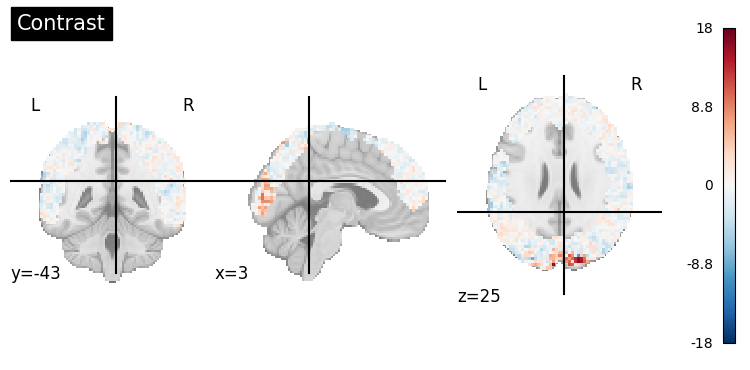

In [37]:
con_map_one_sub(dms, paths)

Mask amygdala
first 2 seconds of the onset
do 2nd level see whether there is any survivor voxels
go on triton
